In [3]:
import os

os.environ["KAGGLE_USERNAME"] = "fatmakuuko"
os.environ["KAGGLE_KEY"] = "KGAT_38636c185b8985b8e5ff76ce488ca72b"

In [4]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import PIL

print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Kurulum kontrol tamam")

TensorFlow: 2.21.0
Pandas: 2.3.3
NumPy: 2.3.5
Kurulum kontrol tamam


In [5]:
import zipfile

!kaggle datasets download -d omkargurav/face-mask-dataset

with zipfile.ZipFile("face-mask-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("İndirme ve çıkarma tamamlandı.")

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown




  0%|          | 0.00/163M [00:00<?, ?B/s]
  1%|          | 1.00M/163M [00:01<03:10, 893kB/s]
  1%|1         | 2.00M/163M [00:01<02:02, 1.38MB/s]
  2%|1         | 3.00M/163M [00:03<02:56, 952kB/s] 
  2%|2         | 4.00M/163M [00:04<03:38, 766kB/s]
  3%|3         | 5.00M/163M [00:07<05:01, 550kB/s]
  4%|3         | 6.00M/163M [00:10<05:38, 487kB/s]
  4%|4         | 7.00M/163M [00:11<04:36, 592kB/s]
  5%|4         | 8.00M/163M [00:12<03:44, 724kB/s]
  6%|5         | 9.00M/163M [00:12<02:57, 910kB/s]
  6%|6         | 10.0M/163M [00:13<02:36, 1.03MB/s]
  7%|6         | 11.0M/163M [00:13<02:10, 1.22MB/s]
  7%|7         | 12.0M/163M [00:14<01:52, 1.40MB/s]
  8%|7         | 13.0M/163M [00:14<01:35, 1.65MB/s]
  9%|8         | 14.0M/163M [00:15<01:35, 1.63MB/s]
  9%|9         | 15.0M/163M [00:15<01:26, 1.79MB/s]
 10%|9         | 16.0M/163M [00:16<01:16, 2.02MB/s]
 10%|#         | 17.0M/163M [00:16<01:09, 2.20MB/s]
 11%|#1        | 18.0M/163M [00:16<01:01, 2.46MB/s]
 12%|#1        | 19.0M/163M

İndirme ve çıkarma tamamlandı.


In [6]:
print("dataset içeriği:", os.listdir("dataset"))
print("dataset/data içeriği:", os.listdir("dataset/data"))

dataset içeriği: ['data']
dataset/data içeriği: ['without_mask', 'with_mask']


In [7]:
data_dir = "dataset/data"
classes = ["with_mask", "without_mask"]

filepaths = []
labels = []

for label in classes:
    class_path = os.path.join(data_dir, label)
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        filepaths.append(fpath)
        labels.append(label)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print(df.head())
print(df["label"].value_counts())
print("Toplam görüntü sayısı:", len(df))

                                    filepath      label
0     dataset/data\with_mask\with_mask_1.jpg  with_mask
1    dataset/data\with_mask\with_mask_10.jpg  with_mask
2   dataset/data\with_mask\with_mask_100.jpg  with_mask
3  dataset/data\with_mask\with_mask_1000.jpg  with_mask
4  dataset/data\with_mask\with_mask_1001.jpg  with_mask
label
without_mask    3828
with_mask       3725
Name: count, dtype: int64
Toplam görüntü sayısı: 7553


In [8]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    stratify=train_val_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 4833
Validation: 1209
Test: 1511


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_val_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

val_generator = test_val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

print("Sınıf indeksleri:", test_generator.class_indices)

Found 4833 validated image filenames belonging to 2 classes.
Found 1209 validated image filenames belonging to 2 classes.
Found 1511 validated image filenames belonging to 2 classes.
Sınıf indeksleri: {'with_mask': 0, 'without_mask': 1}


In [10]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu")(x)
x = Dense(128, activation="relu")(x)
predictions = Dense(2, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,333,058 (27.97 MB)

 Trainable params: 295,554 (1.13 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=5,
    verbose=1,
    min_lr=1e-7
)

checkpoint = ModelCheckpoint(
    "best_densenet121_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/100
113/152 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9269 - loss: 0.1697

C:\Users\Lenovo\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9354 - loss: 0.1532
Epoch 1: val_loss improved from None to 0.01920, saving model to best_densenet121_model.keras

Epoch 1: finished saving model to best_densenet121_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.9599 - loss: 0.1053 - val_accuracy: 0.9934 - val_loss: 0.0192 - learning_rate: 0.0010
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9731 - loss: 0.0780
Epoch 2: val_loss improved from 0.01920 to 0.01409, saving model to best_densenet121_model.keras

Epoch 2: finished saving model to best_densenet121_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.9764 - loss: 0.0641 - val_accuracy: 0.9975 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9824 - loss: 0.0628
Epoch 3: val_loss did not improve from 0.01409
152/152 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.9826 - loss: 0.0597 - val_accuracy: 0.9950 - val

In [13]:
from tensorflow.keras.models import load_model

best_densenet_model = load_model("best_densenet121_model.keras")

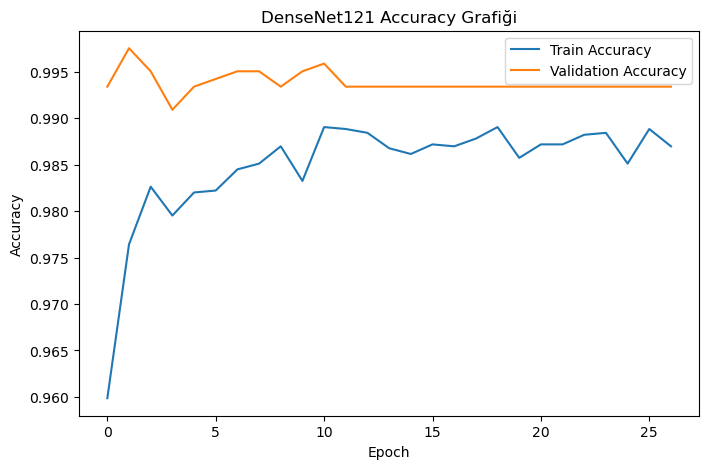

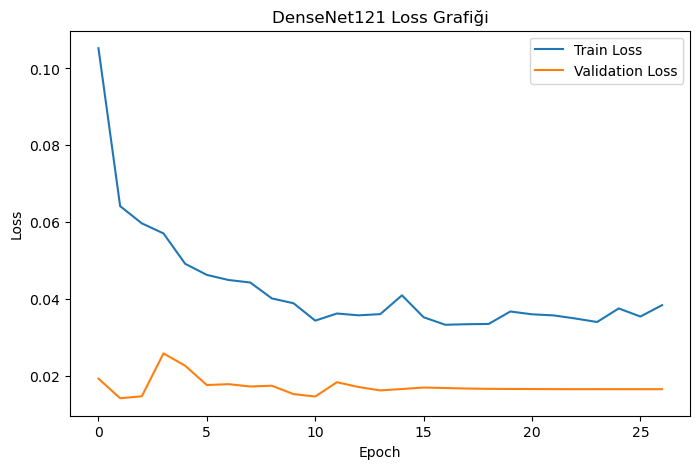

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("DenseNet121 Accuracy Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("DenseNet121 Loss Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [15]:
test_loss, test_accuracy = best_densenet_model.evaluate(test_generator)

print("DenseNet Test Loss:", test_loss)
print("DenseNet Test Accuracy:", test_accuracy)

 5/48 ━━━━━━━━━━━━━━━━━━━━ 39s 911ms/step - accuracy: 0.9907 - loss: 0.0313

C:\Users\Lenovo\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 48s 808ms/step - accuracy: 0.9947 - loss: 0.0166
DenseNet Test Loss: 0.016623588278889656
DenseNet Test Accuracy: 0.9947054982185364


In [16]:
test_generator.reset()
y_pred = best_densenet_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(class_labels)

 5/48 ━━━━━━━━━━━━━━━━━━━━ 39s 916ms/step

C:\Users\Lenovo\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 50s 932ms/step
['with_mask', 'without_mask']


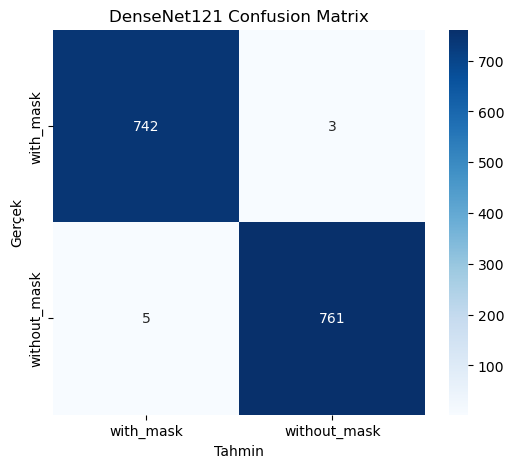

              precision    recall  f1-score   support

   with_mask       0.99      1.00      0.99       745
without_mask       1.00      0.99      0.99       766

    accuracy                           0.99      1511
   macro avg       0.99      0.99      0.99      1511
weighted avg       0.99      0.99      0.99      1511



In [17]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("DenseNet121 Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes)
recall = recall_score(y_true, y_pred_classes)
f1 = f1_score(y_true, y_pred_classes)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("DenseNet Accuracy   :", accuracy)
print("DenseNet Precision  :", precision)
print("DenseNet Recall     :", recall)
print("DenseNet F1-score   :", f1)
print("DenseNet Specificity:", specificity)

DenseNet Accuracy   : 0.9947054930509597
DenseNet Precision  : 0.9960732984293194
DenseNet Recall     : 0.9934725848563969
DenseNet F1-score   : 0.9947712418300654
DenseNet Specificity: 0.9959731543624161


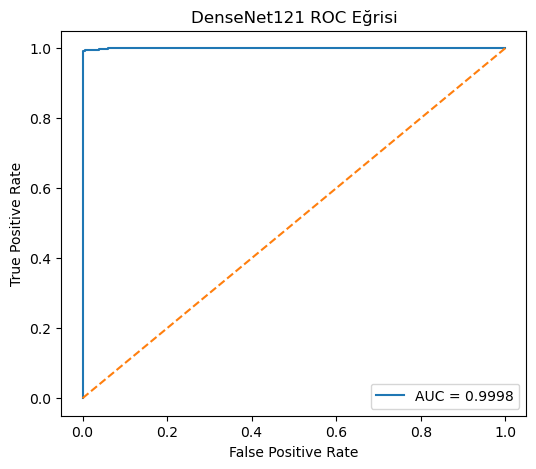

DenseNet AUC: 0.9997599313088125


In [19]:
from sklearn.metrics import roc_curve, auc

positive_class_index = test_generator.class_indices["without_mask"]
fpr, tpr, thresholds = roc_curve(y_true, y_pred[:, positive_class_index])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DenseNet121 ROC Eğrisi")
plt.legend(loc="lower right")
plt.show()

print("DenseNet AUC:", roc_auc)

In [20]:
from tensorflow.keras.applications import MobileNet

base_model_mobilenet = MobileNet(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_mobilenet.trainable = False

x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu")(x)
x = Dense(128, activation="relu")(x)
mobilenet_predictions = Dense(2, activation="softmax")(x)

mobilenet_model = Model(
    inputs=base_model_mobilenet.input,
    outputs=mobilenet_predictions
)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,524,418 (13.44 MB)

 Trainable params: 295,554 (1.13 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [21]:
early_stop_m = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_m = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=5,
    verbose=1,
    min_lr=1e-7
)

checkpoint_m = ModelCheckpoint(
    "best_mobilenet_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [22]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop_m, reduce_lr_m, checkpoint_m]
)

Epoch 1/100
  8/152 ━━━━━━━━━━━━━━━━━━━━ 1:47 745ms/step - accuracy: 0.5810 - loss: 0.8744

C:\Users\Lenovo\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.9088 - loss: 0.2125
Epoch 1: val_loss improved from None to 0.02977, saving model to best_mobilenet_model.keras

Epoch 1: finished saving model to best_mobilenet_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 105s 655ms/step - accuracy: 0.9603 - loss: 0.1053 - val_accuracy: 0.9901 - val_loss: 0.0298 - learning_rate: 0.0010
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9778 - loss: 0.0506
Epoch 2: val_loss did not improve from 0.02977
152/152 ━━━━━━━━━━━━━━━━━━━━ 82s 539ms/step - accuracy: 0.9795 - loss: 0.0501 - val_accuracy: 0.9851 - val_loss: 0.0568 - learning_rate: 0.0010
Epoch 3/100
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.9868 - loss: 0.0412
Epoch 3: val_loss improved from 0.02977 to 0.02976, saving model to best_mobilenet_model.keras

Epoch 3: finished saving model to best_mobilenet_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 83s 544ms/step - accuracy: 0.9843 - loss: 0.0446 - val_accuracy: 0.99

In [23]:
best_mobilenet_model = load_model("best_mobilenet_model.keras")

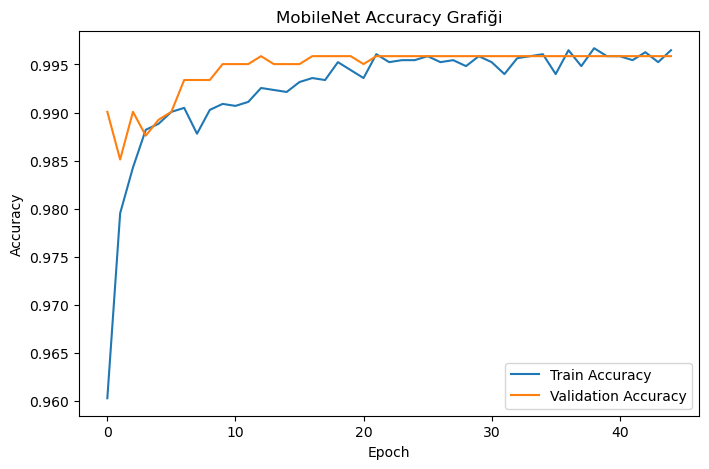

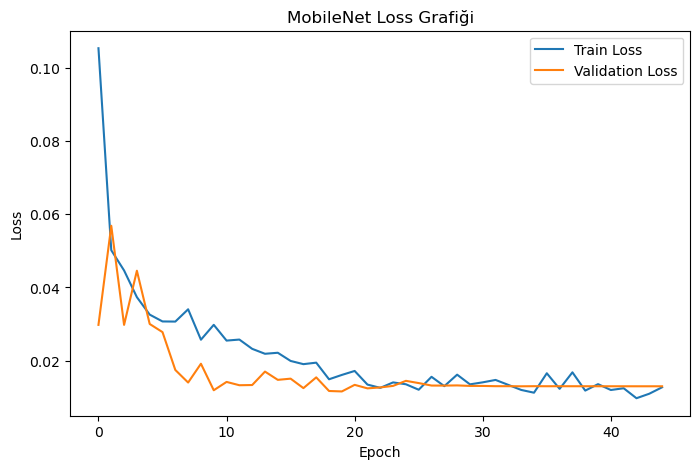

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history_mobilenet.history["accuracy"], label="Train Accuracy")
plt.plot(history_mobilenet.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNet Accuracy Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_mobilenet.history["loss"], label="Train Loss")
plt.plot(history_mobilenet.history["val_loss"], label="Validation Loss")
plt.title("MobileNet Loss Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [25]:
test_loss_m, test_acc_m = best_mobilenet_model.evaluate(test_generator)

print("MobileNet Test Loss:", test_loss_m)
print("MobileNet Test Accuracy:", test_acc_m)

 6/48 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - accuracy: 1.0000 - loss: 0.0102

C:\Users\Lenovo\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.9980 - loss: 0.0074
MobileNet Test Loss: 0.007419134955853224
MobileNet Test Accuracy: 0.9980145692825317


In [26]:
test_generator.reset()
y_pred_m = best_mobilenet_model.predict(test_generator)
y_pred_classes_m = np.argmax(y_pred_m, axis=1)
y_true_m = test_generator.classes
class_labels_m = list(test_generator.class_indices.keys())

print(class_labels_m)

 6/48 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step

C:\Users\Lenovo\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step
['with_mask', 'without_mask']


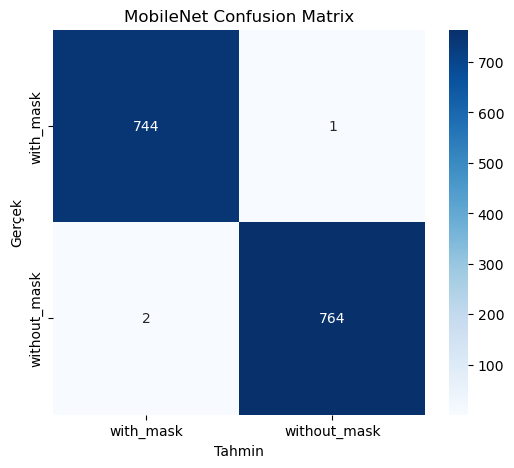

              precision    recall  f1-score   support

   with_mask       1.00      1.00      1.00       745
without_mask       1.00      1.00      1.00       766

    accuracy                           1.00      1511
   macro avg       1.00      1.00      1.00      1511
weighted avg       1.00      1.00      1.00      1511



In [27]:
cm_m = confusion_matrix(y_true_m, y_pred_classes_m)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_m,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels_m,
    yticklabels=class_labels_m
)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("MobileNet Confusion Matrix")
plt.show()

print(classification_report(y_true_m, y_pred_classes_m, target_names=class_labels_m))

In [28]:
accuracy_m = accuracy_score(y_true_m, y_pred_classes_m)
precision_m = precision_score(y_true_m, y_pred_classes_m)
recall_m = recall_score(y_true_m, y_pred_classes_m)
f1_m = f1_score(y_true_m, y_pred_classes_m)

tn_m, fp_m, fn_m, tp_m = cm_m.ravel()
specificity_m = tn_m / (tn_m + fp_m)

print("MobileNet Accuracy   :", accuracy_m)
print("MobileNet Precision  :", precision_m)
print("MobileNet Recall     :", recall_m)
print("MobileNet F1-score   :", f1_m)
print("MobileNet Specificity:", specificity_m)

MobileNet Accuracy   : 0.9980145598941098
MobileNet Precision  : 0.9986928104575163
MobileNet Recall     : 0.9973890339425587
MobileNet F1-score   : 0.9980404964075767
MobileNet Specificity: 0.9986577181208054


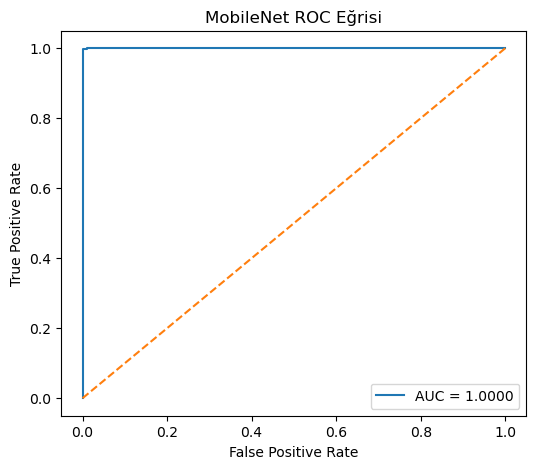

MobileNet AUC: 0.9999772197592304


In [29]:
fpr_m, tpr_m, thresholds_m = roc_curve(y_true_m, y_pred_m[:, positive_class_index])
roc_auc_m = auc(fpr_m, tpr_m)

plt.figure(figsize=(6, 5))
plt.plot(fpr_m, tpr_m, label="AUC = %0.4f" % roc_auc_m)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNet ROC Eğrisi")
plt.legend(loc="lower right")
plt.show()

print("MobileNet AUC:", roc_auc_m)

In [30]:
comparison_df = pd.DataFrame({
    "Model": ["DenseNet121", "MobileNet"],
    "Accuracy": [accuracy, accuracy_m],
    "Precision": [precision, precision_m],
    "Recall": [recall, recall_m],
    "Specificity": [specificity, specificity_m],
    "F1-score": [f1, f1_m],
    "AUC": [roc_auc, roc_auc_m]
})

print(comparison_df)

         Model  Accuracy  Precision    Recall  Specificity  F1-score       AUC
0  DenseNet121  0.994705   0.996073  0.993473     0.995973  0.994771  0.999760
1    MobileNet  0.998015   0.998693  0.997389     0.998658  0.998040  0.999977


In [ ]:
comparison_df.to_csv("model_comparison_results.csv", index=False)
print("Karşılaştırma sonuçları model_comparison_results.csv dosyasına kaydedildi.")

In [ ]:
"""Bu çalışmada Face Mask Detection veri seti kullanılarak DenseNet121 ve MobileNet tabanlı iki farklı pre-trained derin öğrenme modeli geliştirilmiştir. Veri seti önce %80 eğitim+validasyon ve %20 test olarak ayrılmış, ardından eğitim+validasyon kümesi kendi içinde %80 eğitim ve %20 validasyon olarak bölünmüştür. Eğitim verisine veri artırımı uygulanmıştır.

Her iki modelde de temel pre-trained yapı üzerine GlobalAveragePooling, bir Dropout ve iki Dense katmanı eklenmiştir. Eğitim sürecinde 100 epoch planlanmış, ancak EarlyStopping ile validasyon kaybında iyileşme görülmediğinde eğitim erken durdurulabilmiştir. Ayrıca ReduceLROnPlateau kullanılarak öğrenme hızı otomatik olarak azaltılmıştır.

Modeller; accuracy, precision, recall, specificity, F1-score, confusion matrix ve ROC-AUC metrikleri ile değerlendirilmiştir. Elde edilen sonuçlara göre DenseNet121 ve MobileNet modellerinin performansları karşılaştırılmıştır. Daha yüksek doğruluk ve AUC veren model performans açısından daha başarılı kabul edilirken, MobileNet daha hafif bir mimari olduğu için hız ve hesaplama maliyeti açısından avantaj sağlayabilmektedir."""